# **Custom CNN Model for Cucumber_Disease_recognition Task 3**

# **Imports and Setup**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.manual_seed(42)


Using device: cpu


# **Data Preparation**

In [ ]:
class DataPreprocessor:
    def __init__(self, data_path, img_size=224, batch_size=32):

        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        self.class_names = []
        
    def get_transforms(self):
        """Define robust training transforms to prevent overfitting"""
        
        train_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            # --- ENHANCED AUGMENTATION ---
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),  # Leaves can be upside down
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shift image slightly
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            # -----------------------------
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        val_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        return train_transforms, val_transforms
    
    def prepare_dataloaders(self):
        train_transforms, val_transforms = self.get_transforms()
        
        # Load full dataset
        full_dataset = datasets.ImageFolder(root=self.data_path)
        self.class_names = full_dataset.classes
        print(f"Classes: {self.class_names}")
        
        # Split: 70% Train, 15% Val, 15% Test
        total_len = len(full_dataset)
        train_size = int(0.7 * total_len)
        val_size = int(0.15 * total_len)
        test_size = total_len - train_size - val_size
        
        train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])
        
       
        train_ds.dataset.transform = train_transforms
        val_ds.dataset.transform = val_transforms
        test_ds.dataset.transform = val_transforms # Important: Test data should not be augmented
        
        # Determine num_workers based on CPU
        workers = 2 if os.cpu_count() is None else min(4, os.cpu_count())
        
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True, 
                                num_workers=workers, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=self.batch_size, shuffle=False, 
                              num_workers=workers, pin_memory=True)
        test_loader = DataLoader(test_ds, batch_size=self.batch_size, shuffle=False, 
                               num_workers=workers, pin_memory=True)
        
        print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
        return train_loader, val_loader, test_loader

# **Custom CNN Architecture**

In [3]:
class CustomPlantCNN(nn.Module):
    def __init__(self, num_classes=8, dropout_rate=0.5): 
        super(CustomPlantCNN, self).__init__()
        
        # Block 1
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2), # 112x112
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2), # 56x56
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2), # 28x28
            
            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2), # 14x14
            
            # Conv Block 5 (Added Depth)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2), # 7x7
        )
        
        # Global Average Pooling ensures input size to classifier is fixed
        # regardless of spatial dimensions, greatly reducing parameters.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

# **Training**

In [4]:
class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device, scheduler=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.scheduler = scheduler 
        
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
    def train_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for data, targets in tqdm(self.train_loader, desc="Training", leave=False):
            data, targets = data.to(self.device), targets.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
        return running_loss / len(self.train_loader), 100. * correct / total
    
    def validate_epoch(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        return running_loss / len(self.val_loader), 100. * correct / total
    
    def train(self, epochs, patience=7):
        best_val_acc = 0
        patience_counter = 0
        
        print(f"Starting training for {epochs} epochs...")
        
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()
            
            # Scheduler step
            if self.scheduler:
                self.scheduler.step(val_loss) # ReduceLROnPlateau typically monitors loss
            
            # Update history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
                  f"LR: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Early Stopping and Save Best
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_custom_cnn.pth')
                print(f"--> New Best Model Saved (Acc: {best_val_acc:.2f}%)")
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
                
        return self.history

# **Evaluation & Main**

Classes: ['Anthracnose', 'Bacterial Wilt', 'Belly Rot', 'Downy Mildew', 'Fresh Cucumber', 'Fresh Leaf', 'Gummy Stem Blight', 'Pythium Fruit Rot']
Train: 902, Val: 193, Test: 194
Model Parameters: 1,837,320
Starting training for 40 epochs...


Epoch 1/40 | Train Loss: 1.5202 Acc: 48.45% | Val Loss: 1.4412 Acc: 43.01% | LR: 0.000500
--> New Best Model Saved (Acc: 43.01%)


Epoch 2/40 | Train Loss: 1.2601 Acc: 62.08% | Val Loss: 1.0963 Acc: 67.88% | LR: 0.000500
--> New Best Model Saved (Acc: 67.88%)


Epoch 3/40 | Train Loss: 1.1645 Acc: 67.29% | Val Loss: 1.4138 Acc: 65.28% | LR: 0.000500


Epoch 4/40 | Train Loss: 1.0975 Acc: 70.84% | Val Loss: 1.1063 Acc: 65.28% | LR: 0.000500


...

Epoch 36/40 | Train Loss: 0.6609 Acc: 93.90% | Val Loss: 0.7309 Acc: 89.64% | LR: 0.000063


Epoch 37/40 | Train Loss: 0.6633 Acc: 94.35% | Val Loss: 0.7634 Acc: 86.53% | LR: 0.000063


Epoch 38/40 | Train Loss: 0.6572 Acc: 95.45% | Val Loss: 0.7166 Acc: 88.08% | LR: 0.000063


Epoch 39/40 | Train Loss: 0.6741 Acc: 94.24% | Val Loss: 0.7184 Acc: 87.56% | LR: 0.000063


Epoch 40/40 | Train Loss: 0.6536 Acc: 95.57% | Val Loss: 0.7199 Acc: 86.53% | LR: 0.000063


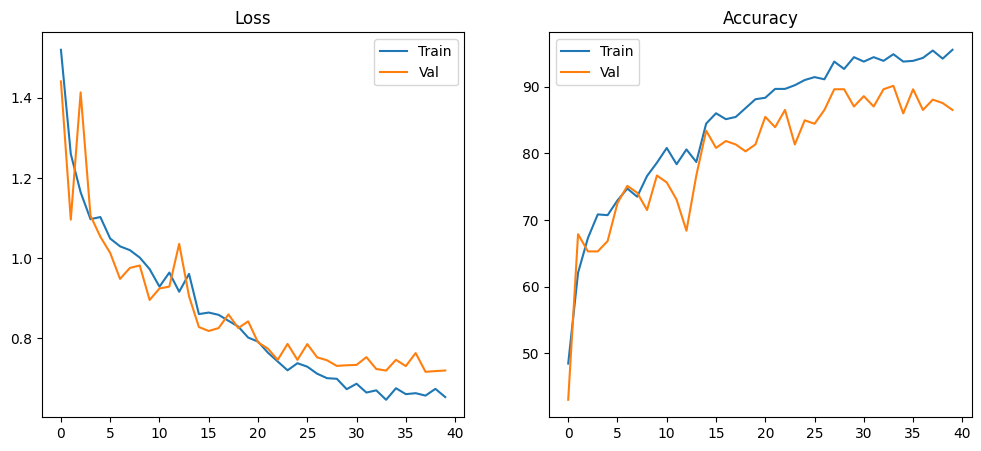


FINAL TEST EVALUATION
                   precision    recall  f1-score   support

      Anthracnose       0.70      0.59      0.64        27
   Bacterial Wilt       0.84      0.91      0.87        23
        Belly Rot       0.93      0.93      0.93        27
     Downy Mildew       0.65      0.92      0.76        24
   Fresh Cucumber       1.00      0.91      0.95        22
       Fresh Leaf       0.83      0.75      0.79        20
Gummy Stem Blight       0.76      0.62      0.68        26
Pythium Fruit Rot       0.96      1.00      0.98        25

         accuracy                           0.82       194
        macro avg       0.83      0.83      0.83       194
     weighted avg       0.83      0.82      0.82       194



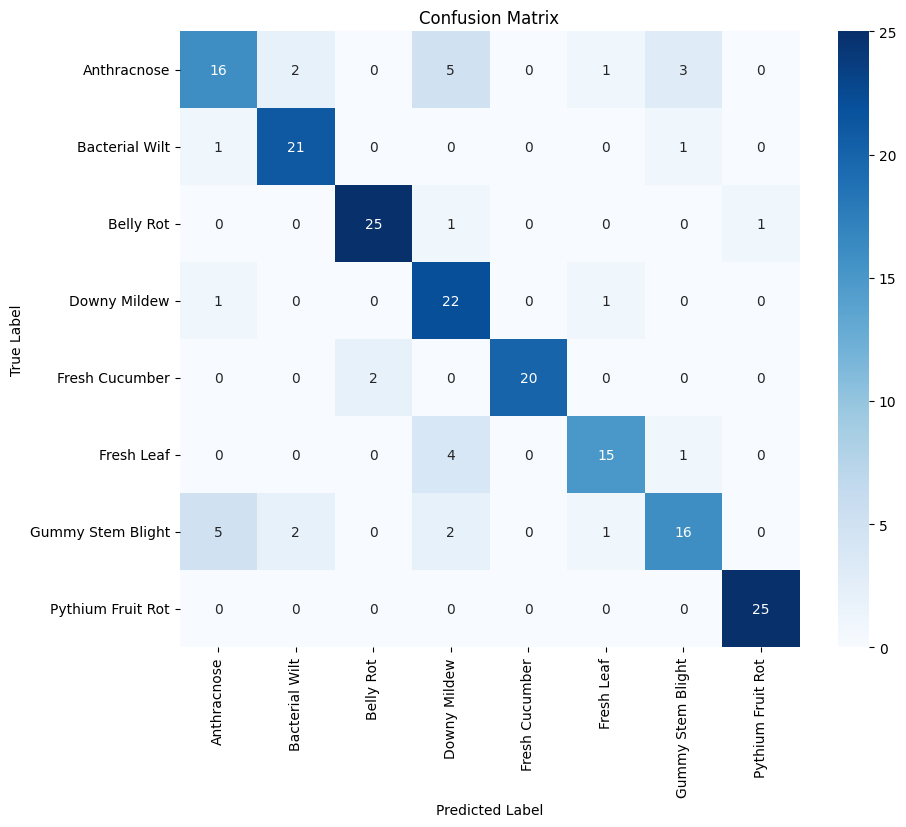

In [ ]:
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    # Metrics
    print("\n" + "="*30)
    print("FINAL TEST EVALUATION")
    print("="*30)
    print(classification_report(all_targets, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def main():
    # --- CONFIGURATION ---
    DATA_PATH = "/kaggle/input/cucumber-disease-recognition-dataset/Original Image"
    IMG_SIZE = 224      
    BATCH_SIZE = 32
    LEARNING_RATE = 0.0005 
    EPOCHS = 40          
    PATIENCE = 8         
    DROPOUT_RATE = 0.5

    # 1. Prepare Data
    preprocessor = DataPreprocessor(DATA_PATH, IMG_SIZE, BATCH_SIZE)
    train_loader, val_loader, test_loader = preprocessor.prepare_dataloaders()
    
    # 2. Initialize Model
    model = CustomPlantCNN(num_classes=len(preprocessor.class_names), dropout_rate=DROPOUT_RATE).to(device)
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # 3. Loss & Optimizer
    # Label Smoothing helps prevent overconfidence and improves generalization
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
    # AdamW is generally better than Adam for image classification
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) 
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    # 4. Train
    trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, device, scheduler)
    history = trainer.train(EPOCHS, PATIENCE)
    
    # 5. Plot History
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    plt.show()
    
    # 6. Final Evaluation
    model.load_state_dict(torch.load('best_custom_cnn.pth'))
    evaluate_model(model, test_loader, device, preprocessor.class_names)

if __name__ == "__main__":
    main()